In [1]:
# LOAD LIBRARIES.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib, time
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')

from IPython.display import clear_output

from python import forces, integrators, random_matrix, simulate, densities, plotters
importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities); importlib.reload(plotters);

from python import fmm; importlib.reload(fmm);

---
FMM. See the written notes. Expect that need $N$ to be moderate-large in order for the overhead to be worth it: try also the Barnes-Hut version?


**Later check errors for these versions - has been done before.**

In [2]:
direct_func = forces.coulomb_interaction
fmm_func = fmm.fmm_coulomb_1d
bh_func = fmm.barnes_hut_coulomb_1d
M = 1;

def calc_fmm_err(exact, fmm):
    return np.max(np.abs(exact - fmm))

def fmm_vs_direct(N_values, num_trials = 3):
    """ 
    Benchmark direct O(N^2) Coulomb calculation against the FMM method implemented.
    Expect much better asymptotic performance: main goal is to find the point where FMM is favourable.
    Using clock time...
    """

    direct_times = []; fmm_times = []; bh_times = [];
    
    # Warm up the Numba functions.
    dummy_x = np.random.normal(0, 1, 10)
    _ = direct_func(dummy_x); _ = fmm_func(dummy_x); _ = bh_func(dummy_x)
    print("Warm up finished.")

    for N in N_values:
        N = int(N)
        clear_output(wait = True)
        print(f"Working on N = {N}.")
        x = random_matrix.init_gue_eigenvalues(M, N).reshape((N,))
        
        # Direct method.
        if (N <= 5000):
            start_time_direct = time.perf_counter()
            for _ in range(num_trials):
                _ = direct_func(x)
            
            end_time_direct = time.perf_counter()
            direct_times.append((end_time_direct - start_time_direct)/num_trials)

        # FMM.
        start_time_fmm = time.perf_counter()
        for _ in range(num_trials):
            fmm = fmm_func(x)
        
        end_time_fmm = time.perf_counter()
        fmm_times.append((end_time_fmm - start_time_fmm)/num_trials)

        # Barnes_hut.
        start_time_bh = time.perf_counter()
        for _ in range(num_trials):
            _ = bh_func(x)

        end_time_bh = time.perf_counter()
        bh_times.append((end_time_bh - start_time_bh)/num_trials)

    return direct_times, fmm_times, bh_times

In [3]:
N_values = np.logspace(np.log10(100), np.log10(5000), 20); num_trials = 20
direct_times, fmm_times, bh_times = fmm_vs_direct(N_values, num_trials = num_trials)

Working on N = 4999.


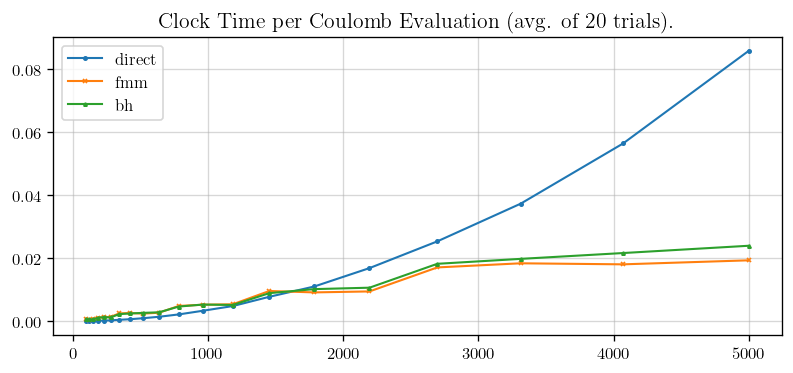

Direct slope 1.97, FMM slope 1.00, BH slope 1.03.


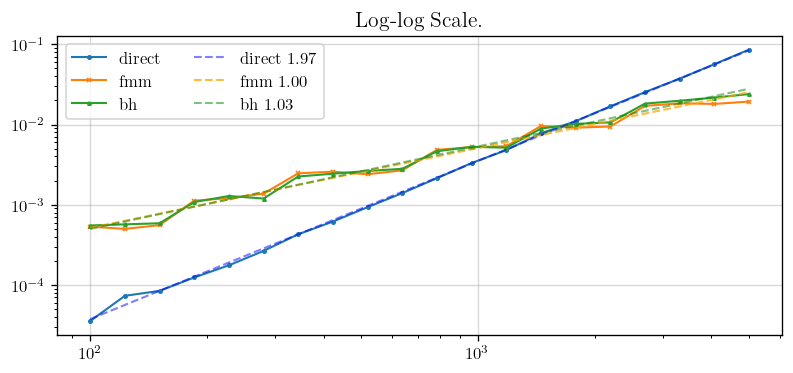

In [4]:
fig, ax = plt.subplots()
ax.plot(N_values, direct_times, marker = 'o', label = "direct")
ax.plot(N_values, fmm_times, marker = 'x', label = "fmm")
ax.plot(N_values, bh_times, marker = '^', label = "bh")
ax.set_title(f"Clock Time per Coulomb Evaluation (avg. of {num_trials} trials).")
ax.legend()

plt.show()

fig, ax = plt.subplots()
ax.loglog(N_values, direct_times, marker = 'o', label = "direct")
ax.loglog(N_values, fmm_times, marker = 'x', label = "fmm")
ax.loglog(N_values, bh_times, marker = '^', label = "bh")

# Regression lines.
log_N = np.log10(N_values); log_direct = np.log10(direct_times); log_fmm = np.log10(fmm_times); log_bh = np.log10(bh_times)
direct_slope, direct_intercept = np.polyfit(log_N, log_direct, 1) # polyfit(x, y, degree), returns slope, intercept.
fmm_slope, fmm_intercept = np.polyfit(log_N, log_fmm, 1)
bh_slope, bh_intercept = np.polyfit(log_N, log_bh, 1)

ax.plot(N_values, 10**(direct_intercept)*N_values**direct_slope, color = "blue", linestyle = '--', alpha = 0.5, label = f"direct {direct_slope:.2f}")
ax.plot(N_values, 10**(fmm_intercept)*N_values**fmm_slope, color = "orange", linestyle = '--', alpha = 0.75, label = f"fmm {fmm_slope:.2f}")
ax.plot(N_values, 10**(bh_intercept)*N_values**bh_slope, color = "green", linestyle = '--', alpha = 0.5, label = f"bh {bh_slope:.2f}")

ax.set_title(f"Log-log Scale.")
ax.legend(ncols = 2)

print(f"Direct slope {direct_slope:.2f}, FMM slope {fmm_slope:.2f}, BH slope {bh_slope:.2f}.")
plt.show()